In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import motornet as mn

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)
print("motornet", mn.__version__)

motornet 0.3.0


In [22]:
from MotorNetUtils.skeleton import NLinkArm

skeleton = NLinkArm(
    m=[1.9, 1.5, 0.5], l=[0.30, 0.20, 0.10], lg=[0.16, 0.16, 0.07], i=[0.013, 0.020, 0.003],
    pos_lower_bound=np.deg2rad([0, 0, 0]), pos_upper_bound=np.deg2rad([145, 160, 20]),
)
muscle = mn.muscle.ReluMuscle()
effector = mn.effector.Effector(
    skeleton=skeleton,
    muscle=muscle,
    timestep=0.01,
)

muscles = [
    ([0, 1], [[-0.1,  0.0], [0.12, 0.0]], 1000, "flx_01"),
    ([0, 1], [[0.1,  0.0], [0.15, 0.0]],  900, "ext_01"),
    ([0, 1, 2], [[0.08,  0.0], [0.32, -.01],  [0.13, 0.0]],  550, "ext_012"),
    ([1, 2], [[0.10,  0.0], [0.10, 0.0]],  600, "flx_12"),
    ([1, 1, 2], [[0.2,  0.0], [0.32, -.02],  [0.13, 0.0]],  550, "ext_112"),
    ([0, 2], [[-0.03,  0.0], [0.10, 0.0]],  500, "flx_02"),
    ([1, 3], [[0.03,  0.0], [0.05, 0.0]],  500, "flx_13"),
    ([2, 2, 3], [[0.12,  0.0], [0.2, 0.02], [0.03, 0.0]],  500, "flx_223"),
    ([2, 2, 3], [[0.12,  0.0], [0.2, -0.02], [0.03, 0.0]],  500, "ext_223"),
]

for fixation, coords, force, name in muscles:
    effector.add_muscle(
        path_fixation_body=fixation,
        path_coordinates=coords,
        max_isometric_force=force,
        name=name,
    )

print("degrees of freedom:", effector.skeleton.dof)
print("number of muscles :", effector.n_muscles)
effector.print_muscle_wrappings()

degrees of freedom: 3
number of muscles : 9
MUSCLE NAME: flx_01
-------------------
n_fixation_points:  2
fixation body:  [0, 1]
coordinates:  [[-0.10000000149011612, 0.0], [0.11999999731779099, 0.0]]
max_isometric_force:  1000


MUSCLE NAME: ext_01
-------------------
n_fixation_points:  2
fixation body:  [0, 1]
coordinates:  [[0.10000000149011612, 0.0], [0.15000000596046448, 0.0]]
max_isometric_force:  900


MUSCLE NAME: ext_012
--------------------
n_fixation_points:  3
fixation body:  [0, 1, 2]
coordinates:  [[0.07999999821186066, 0.0], [0.3199999928474426, -0.009999999776482582], [0.12999999523162842, 0.0]]
max_isometric_force:  550


MUSCLE NAME: flx_12
-------------------
n_fixation_points:  2
fixation body:  [1, 2]
coordinates:  [[0.10000000149011612, 0.0], [0.10000000149011612, 0.0]]
max_isometric_force:  600


MUSCLE NAME: ext_112
--------------------
n_fixation_points:  3
fixation body:  [1, 1, 2]
coordinates:  [[0.20000000298023224, 0.0], [0.3199999928474426, -0.01999999955

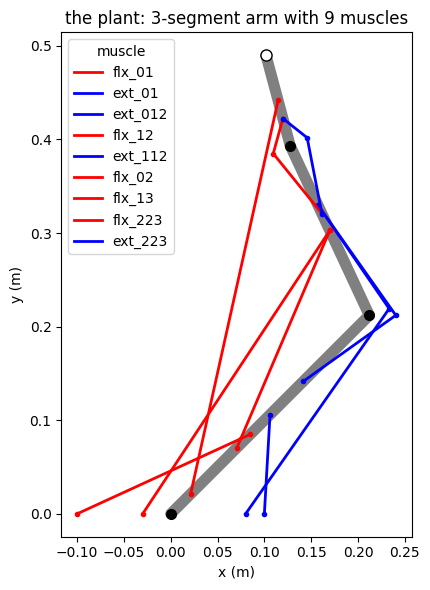

In [23]:
from MotorNetUtils.vis import draw_arm

lengths = [getattr(effector.skeleton, f"l{k + 1}") for k in range(effector.skeleton.dof)]
example_q = np.zeros(len(lengths))
example_q[:3] = np.deg2rad([45, 70, -10])

fig, ax = plt.subplots(figsize=(6, 6))
draw_arm(fig, ax, example_q, lengths, muscles)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"the plant: {len(lengths)}-segment arm with {len(muscles)} muscles")
ax.legend(title="muscle", loc="upper left")
plt.tight_layout()
plt.show()

In [24]:
from MotorNetUtils.environment import CentreOutReach

env = CentreOutReach(effector=effector, max_ep_duration=1.0)

obs_dim = env.observation_space.shape[0]
n_muscles = env.n_muscles
print("observation dim:", obs_dim)
print("action dim (muscles):", n_muscles)

observation dim: 22
action dim (muscles): 9


In [25]:
policy = mn.policy.PolicyGRU(obs_dim, 128, n_muscles, device=device)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

n_dof = effector.skeleton.dof

def run_episode(batch_size):
    """Roll out one batch of reaches; return hand-xy, target-xy, actions, joint angles."""
    h = policy.init_hidden(batch_size=batch_size)
    obs, info = env.reset(options={"batch_size": batch_size})
    xy, tg, acts, joints = [], [], [], []
    terminated = False
    while not terminated:
        action, h = policy(obs, h)
        obs, _, terminated, _, info = env.step(action=action)
        xy.append(info["states"]["fingertip"][:, None, :])         # hand position
        tg.append(info["goal"][:, None, :])                        # target position
        acts.append(action[:, None, :])
        joints.append(info["states"]["joint"][:, None, :n_dof])    # joint angles (all dof)
    return (torch.cat(xy, dim=1), torch.cat(tg, dim=1),
            torch.cat(acts, dim=1), torch.cat(joints, dim=1))

In [26]:
batch_size = 32
n_batches = 20000          # the MotorNet example trains for ~6000; raise for cleaner reaches
losses = []

for b in range(n_batches):
    xy, tg, acts, _ = run_episode(batch_size)
    pos_loss = torch.mean(torch.sum(torch.abs(xy - tg), dim=-1))
    effort = 1e-3 * torch.mean(torch.sum(acts ** 2, dim=-1))
    loss = pos_loss + effort

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)  # stabilises training
    if all(torch.isfinite(g.grad).all() for g in policy.parameters() if g.grad is not None):
        optimizer.step()       # skip the step if any gradient is non-finite

    losses.append(loss.item())
    if (b + 1) % 50 == 0:
        print(f"batch {b + 1:4d} | loss {loss.item():.4f} (pos {pos_loss.item():.4f})")

batch   50 | loss 0.1085 (pos 0.1085)
batch  100 | loss 0.1125 (pos 0.1125)
batch  150 | loss 0.1033 (pos 0.1033)
batch  200 | loss 0.0862 (pos 0.0862)
batch  250 | loss 0.0724 (pos 0.0724)
batch  300 | loss 0.0753 (pos 0.0753)
batch  350 | loss 0.0665 (pos 0.0665)
batch  400 | loss 0.0552 (pos 0.0552)
batch  450 | loss 0.0629 (pos 0.0629)
batch  500 | loss 0.0555 (pos 0.0555)
batch  550 | loss 0.0514 (pos 0.0514)
batch  600 | loss 0.0481 (pos 0.0481)
batch  650 | loss 0.0516 (pos 0.0516)
batch  700 | loss 0.0460 (pos 0.0460)
batch  750 | loss 0.0430 (pos 0.0430)
batch  800 | loss 0.0422 (pos 0.0422)
batch  850 | loss 0.0415 (pos 0.0415)
batch  900 | loss 0.0425 (pos 0.0425)
batch  950 | loss 0.0399 (pos 0.0399)
batch 1000 | loss 0.0374 (pos 0.0374)
batch 1050 | loss 0.0379 (pos 0.0379)
batch 1100 | loss 0.0392 (pos 0.0392)
batch 1150 | loss 0.0400 (pos 0.0400)
batch 1200 | loss 0.0367 (pos 0.0366)
batch 1250 | loss 0.0381 (pos 0.0381)
batch 1300 | loss 0.0382 (pos 0.0382)
batch 1350 |

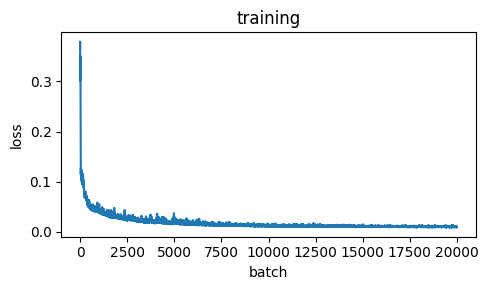

In [27]:
plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("batch") 
plt.ylabel("loss")
plt.title("training")
plt.tight_layout()
plt.show()

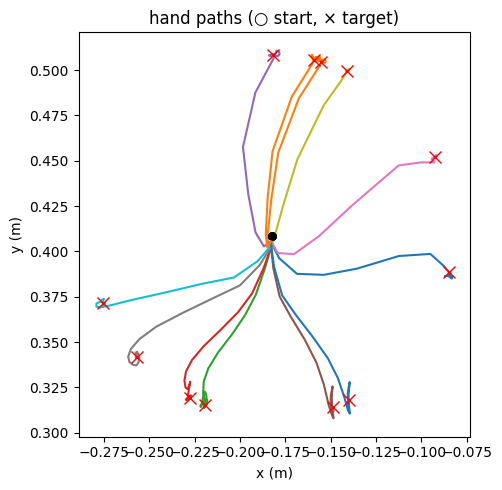

In [31]:
with torch.no_grad():
    xy, tg, acts, joints = run_episode(batch_size=12)
xy, tg = xy.numpy(), tg.numpy()

plt.figure(figsize=(5, 5))
for i in range(xy.shape[0]):
    plt.plot(xy[i, :, 0], xy[i, :, 1], lw=1.5)
    plt.plot(xy[i, 0, 0], xy[i, 0, 1], "o", color="k", ms=5)        # start
    plt.plot(tg[i, -1, 0], tg[i, -1, 1], "x", color="r", ms=9)      # target
plt.gca().set_aspect("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("hand paths (○ start, × target)")
plt.tight_layout()
plt.show()

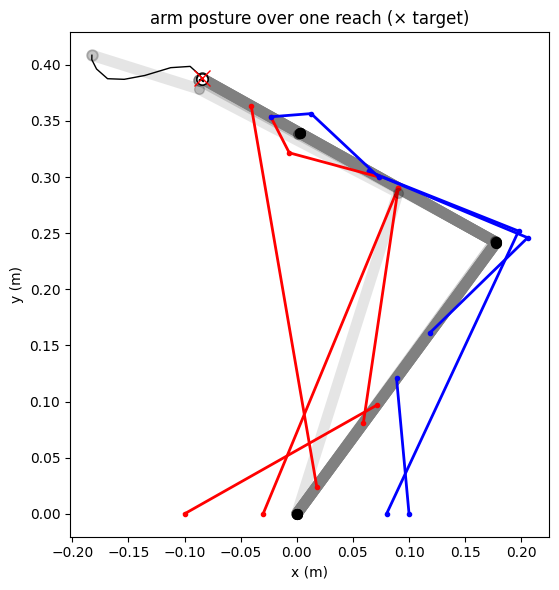

In [32]:
# Arm posture along one reach: faint early postures -> bold final posture.
joints_np = joints[0].numpy()
T = joints_np.shape[0]
frames = np.linspace(0, T - 1, 6).astype(int)

fig, ax = plt.subplots(figsize=(6, 6))
for j, t in enumerate(frames):
    a = 0.2 + 0.8 * j / (len(frames) - 1)
    draw_arm(fig, ax, joints_np[t], lengths, muscles, alpha=a, muscles_on=(t == frames[-1]))
ax.plot(xy[0, :, 0], xy[0, :, 1], "-", color="k", lw=1, zorder=4)
ax.plot(tg[0, -1, 0], tg[0, -1, 1], "x", color="r", ms=11, zorder=5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("arm posture over one reach (× target)")
plt.tight_layout()
plt.show()

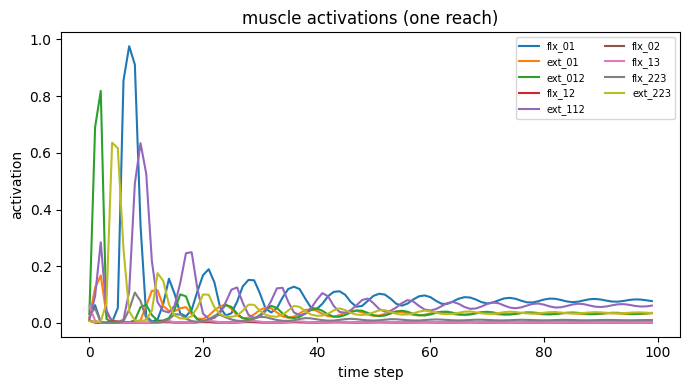

In [34]:
# Muscle activations over time for one reach (shows the redundant control).
a = acts[0].numpy()
plt.figure(figsize=(7, 4))
for m in range(a.shape[1]):
    plt.plot(a[:, m], label=effector.muscle_name[m])
plt.xlabel("time step")
plt.ylabel("activation")
plt.title("muscle activations (one reach)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()